In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [2]:
#loading the datasets
training_path = r'C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\data\\raw\\train_F3WbcTw_1icmK82.csv'
test_path = r'C:\\Users\\GIGABYTE\\Desktop\\drug-sentiment-analysis\\data\\raw\\test_tOlRoBf_VeRQtHl.csv'
training_data = pd.read_csv(training_path)
test_data = pd.read_csv(test_path)

In [9]:
#see first 5 rows of dataset
training_data.head()

,unique_hash,text,drug,sentiment
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1


In [ ]:
#checking the shape of the datasets
print('training data shape:', training_data.shape)
print('test data shape:', test_data.shape)

training data shape: (5279, 4)
test data shape: (2924, 3)


In [15]:
#info about the dataset
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5279 entries, 0 to 5278
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   unique_hash  5279 non-null   object
 1   text         5279 non-null   object
 2   drug         5279 non-null   object
 3   sentiment    5279 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 165.1+ KB


In [17]:
#checking for missing values
training_data.isnull().sum()

unique_hash    0
text           0
drug           0
sentiment      0
dtype: int64

In [12]:
#value counts of target variable
training_data['sentiment'].value_counts()

sentiment
2    3825
1     837
0     617
Name: count, dtype: int64

we have imbalanced target data

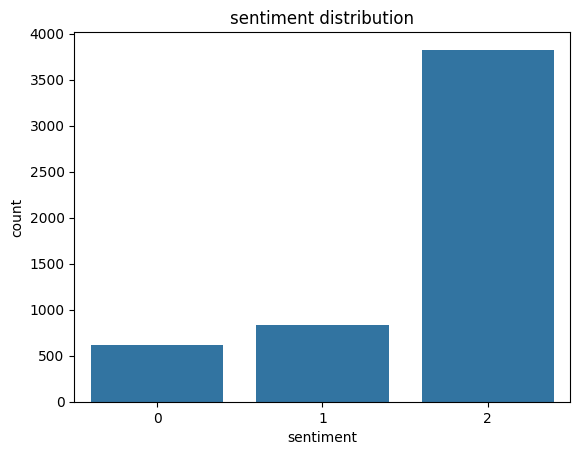

In [14]:
#ploting the distribution of target variable
sns.countplot(x='sentiment', data=training_data)
plt.title('sentiment distribution');

In [19]:
#checking drugs mentioned
training_data["drug"].value_counts().head(10)

drug
ocrevus        676
gilenya        666
ocrelizumab    441
entyvio        303
humira         270
fingolimod     238
remicade       229
opdivo         224
tarceva        218
cladribine     200
Name: count, dtype: int64

In [23]:
training_data["drug"].value_counts().tail(10)

drug
brigatinib     1
pegaptanib     1
alemtuzumab    1
rhumab 2h7     1
filgotinib     1
alectnib       1
crizotnib      1
ct-p13         1
guselkumab     1
cyramza        1
Name: count, dtype: int64

In [24]:
training_data["drug"].nunique()

102

In [22]:
training_data.sample(5)['text'].values

array(["My husband (age 25, a non smoker and non alcoholic) has been diagnosed with NSCLC for 5 months. When was diaggonisrd the primary tumor size was 8.2 cm * 5.0 cm in left lung with multiple nodules in both lung and mild plural effusion. According the biopsy he is having stage lV adinocarcinoma and unfortunately both EGFR and ALK mutations came negative. Still waiting for ROS1 mutation result. As the first line treatment he has taken four cycles of chemotherapy with pemetrexed and carbo every three weeks. After 4 cycles CT reveals the tumor have shirnked to 3.7 cm * 2.8 cm and nodules is still present. Now he is on pemetrexed maintenance and taken four cycle of it and his next CT is on 5th of November. He taking treatment at Tata Memorial Hospital, Mumbai, India. I'm anxious about his next treatment. Now we are thinking about two options. 1. CimaVax/ Vaxira treatment in Cuba: I've contacted to La Predira Hospital, Havana and sent all the medical documents. They have replied that my

In [25]:
training_data['text'][0]

'Autoimmune diseases tend to come in clusters. As for Gilenya – if you feel good, don’t think about it, it won’t change anything but waste your time and energy. I’m taking Tysabri and feel amazing, no symptoms (other than dodgy color vision, but I’ve had it since always, so, don’t know) and I don’t know if it will last a month, a year, a decade, ive just decided to enjoy the ride, no point in worrying.'

In [ ]:
#checking for duplicates
training_data.duplicated().sum()

np.int64(0)

In [45]:
training_data.groupby('drug')['sentiment'].value_counts().unstack().fillna(0).div(training_data.groupby('drug')['sentiment'].value_counts().unstack().fillna(0).sum(axis=1), axis=0).head(20)

sentiment,0,1,2
drug,,,
afatinib,0.100000,0.100000,0.800000
aflibercept,0.000000,0.000000,1.000000
alecensa,0.300000,0.000000,0.700000
alectinib,0.255814,0.069767,0.674419
alectnib,0.000000,0.000000,1.000000
alemtuzumab,0.000000,0.000000,1.000000
alimta,0.075342,0.130137,0.794521
almita,0.500000,0.000000,0.500000
alunbrig,0.000000,1.000000,0.000000


<Axes: xlabel='drug'>

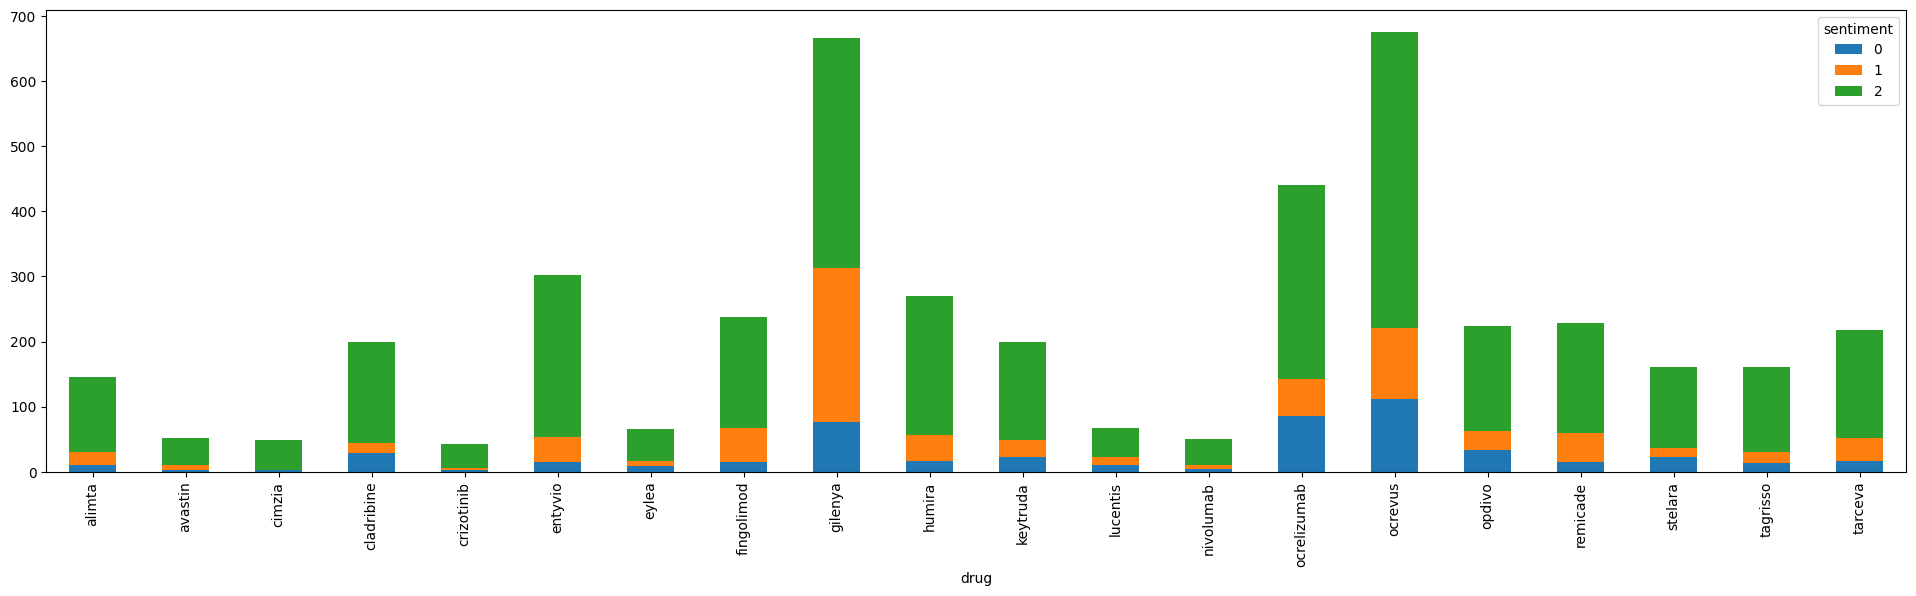

In [44]:
top_drugs = training_data['drug'].value_counts().head(20).index

training_data[training_data['drug'].isin(top_drugs)] \
.groupby(['drug','sentiment']) \
.size() \
.unstack() \
.fillna(0) \
.plot(kind='bar', stacked=True, figsize=(24,6))

<Axes: xlabel='drug'>

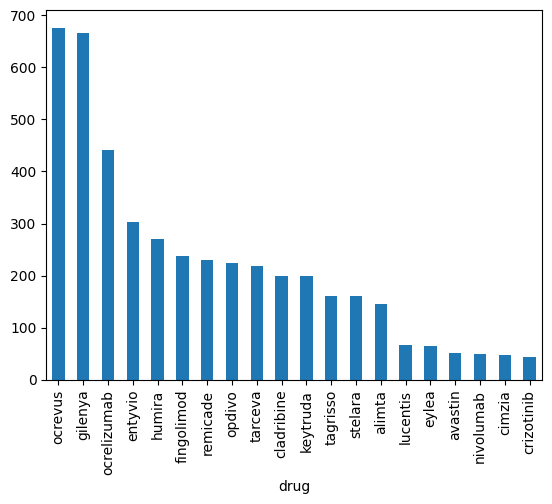

In [47]:
training_data['drug'].value_counts().head(20).plot(kind='bar')

In [48]:
from collections import Counter

all_words = " ".join(training_data['text']).split()
Counter(all_words).most_common(20)

[('the', 61123),
 ('of', 44248),
 ('to', 43476),
 ('and', 43014),
 ('a', 29922),
 ('in', 29153),
 ('I', 24562),
 ('for', 20700),
 ('is', 19172),
 ('with', 18878),
 ('that', 16090),
 ('or', 13162),
 ('on', 12287),
 ('have', 10863),
 ('was', 10141),
 ('be', 9891),
 ('it', 9480),
 ('you', 9445),
 ('are', 9397),
 ('my', 9185)]

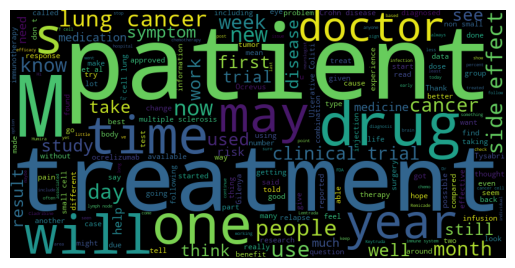

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(training_data['text'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# observation

1. Dataset Size

The training dataset contains 5,279 observations, each representing a user comment associated with a specific drug and its corresponding sentiment label.

Implication:
This dataset size is relatively small for deep learning models, which suggests that traditional machine learning algorithms may perform well.

2. Number of Unique Drugs

There are 102 unique drugs present in the training dataset.

Implication:
This indicates that the dataset covers a wide range of medications, and sentiment patterns may vary across different drugs.

3. Imbalanced Sentiment Distribution

The sentiment column shows a class imbalance, where one sentiment class appears significantly more frequently than the others.

Implication:
use stritify when splitting data
Class imbalance may affect model performance, so evaluation metrics such as F1-score will be important when comparing models.


4. Neutral Sentiment Dominates

A large proportion of the comments express neutral sentiment toward the drugs.

Implication:
The model may become biased toward predicting the neutral class if class imbalance is not considered during training.

5. Drug Frequency Distribution

The drug "Ocrevus" appears most frequently in the dataset, making it the most discussed medication in the training data.

Implication:
Certain drugs may dominate the dataset, which could influence model learning if not properly considered.